##### US Visa Prediction Project
##### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Exploratory data analysis
- Data Cleaning
- Data Pre-Processing
- Model Training
- Choose best model

##### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

##### 1) Problem statement.
OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications.
As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.
In this project we are going to use the data given to build a Classification model:

This model is to check if Visa get approved or not based on the given dataset.
This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.
##### 2) Data Collection.
The Dataset is part of Office of Foreign Labor Certification (OFLC)
The data consists of 25480 Rows and 12 Columns
https://www.kaggle.com/datasets/moro23/easyvisa-dataset

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import math

warnings.filterwarnings("ignore")

%matplotlib inline

In [24]:
df = pd.read_csv(r"Easyvisa.csv")

In [25]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [26]:
df.shape

(25480, 12)

In [27]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [29]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 12 numerical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'region_of_employment', 'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status']

We have 0 categorical features : []


In [30]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Numerical Features:
['no_of_employees', 'yr_of_estab', 'prevailing_wage']


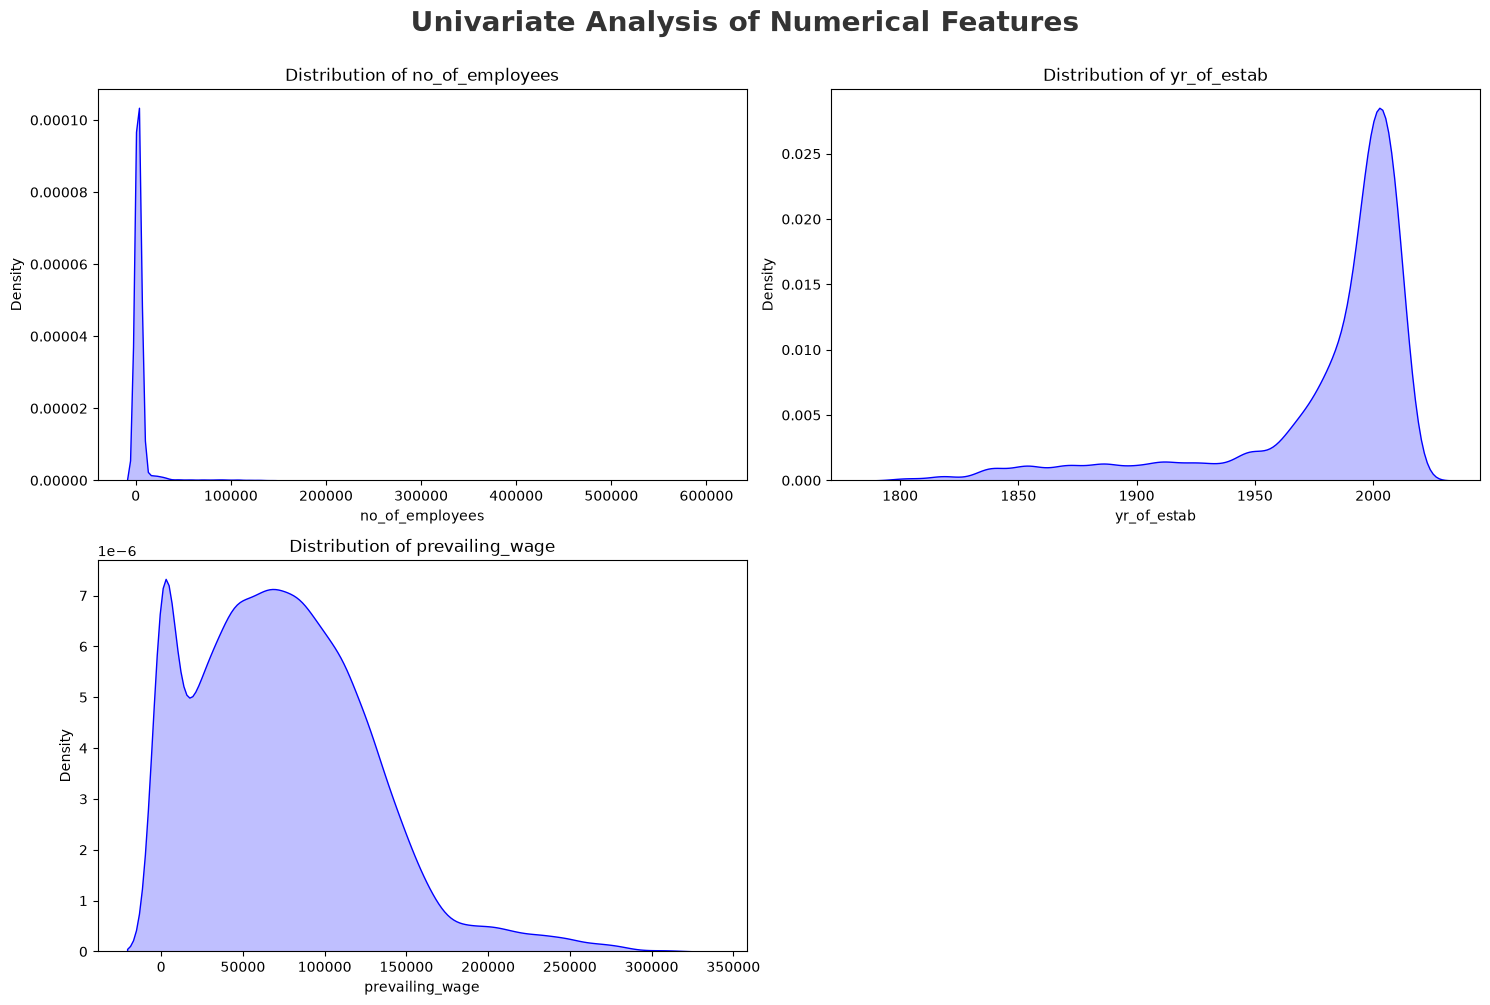

In [31]:
# Select only numerical features
numeric_features = df.select_dtypes(include='number').columns.tolist()

print("Numerical Features:")
print(numeric_features)

# Number of columns and rows for subplots
cols = 2
rows = math.ceil(len(numeric_features) / cols)

# Create figure
plt.figure(figsize=(15, 5 * rows))

plt.suptitle(
    'Univariate Analysis of Numerical Features',
    fontsize=20,
    fontweight='bold',
    alpha=0.8,
    y=1.0
)

# Plot KDE for each numerical feature
for i, feature in enumerate(numeric_features):

    plt.subplot(rows, cols, i + 1)

    sns.kdeplot(
        x=df[feature].dropna(),
        color='blue',
        fill=True
    )

    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'Distribution of {feature}')

# Adjust layout
plt.tight_layout()

# Save plot
# plt.savefig('./images/Univariate_Num.png', bbox_inches='tight')

plt.show()

Categorical Features:
['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


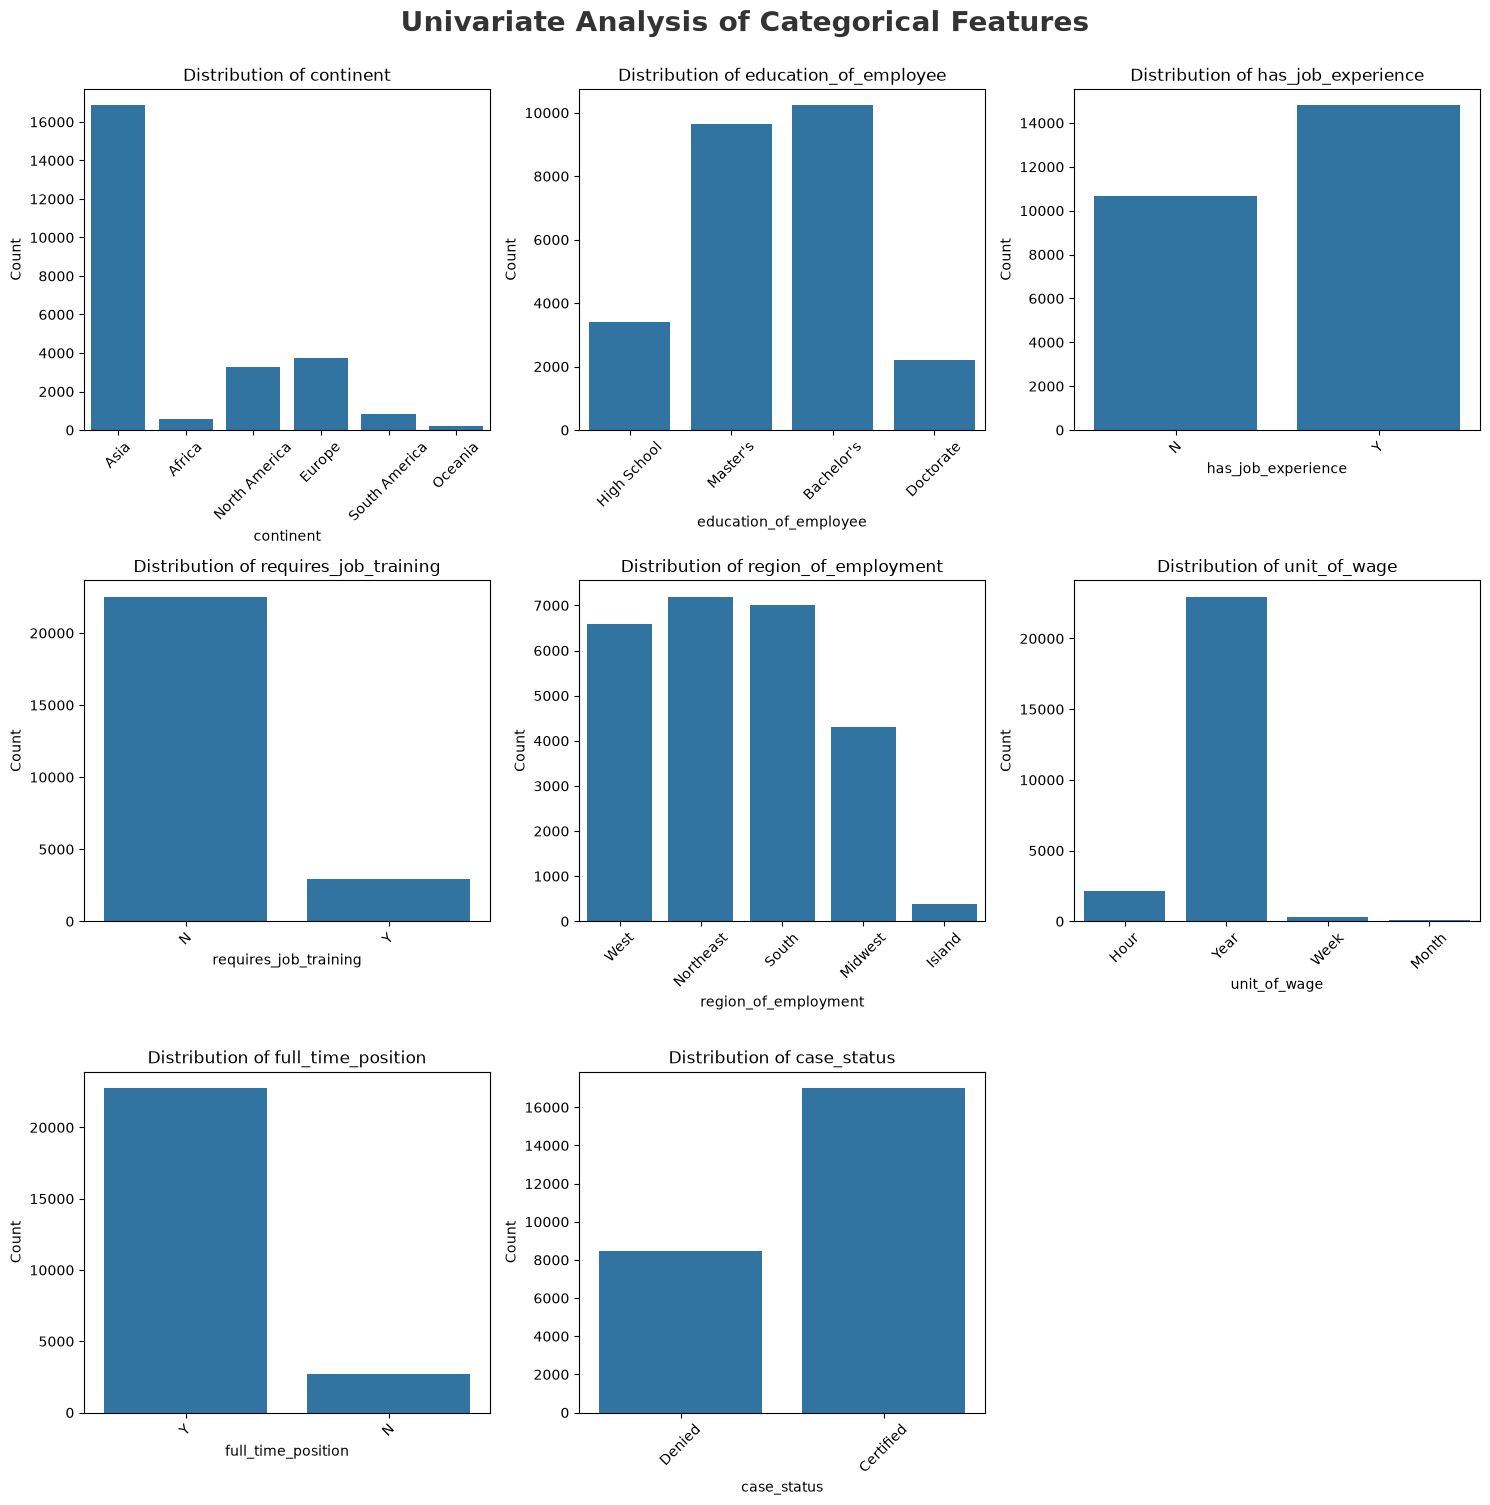

In [33]:
# Select categorical features automatically
categorical_features = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Remove case_id if it exists
if 'case_id' in categorical_features:
    categorical_features.remove('case_id')

print("Categorical Features:")
print(categorical_features)

# Number of columns and rows
cols = 3
rows = math.ceil(len(categorical_features) / cols)

# Create figure
plt.figure(figsize=(15, 5 * rows))

plt.suptitle(
    'Univariate Analysis of Categorical Features',
    fontsize=20,
    fontweight='bold',
    alpha=0.8,
    y=1.0
)

# Plot countplot for each categorical feature
for i, feature in enumerate(categorical_features):

    plt.subplot(rows, cols, i + 1)

    sns.countplot(
        x=df[feature]
    )

    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'Distribution of {feature}')

    # Rotate labels if necessary
    plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Save plot
# plt.savefig('./images/Univariate_Cat.png', bbox_inches='tight')

plt.show()

In [34]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [35]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [36]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


In [37]:

df.isnull().sum()


case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [38]:

continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :',continues_features)

Num of continues features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


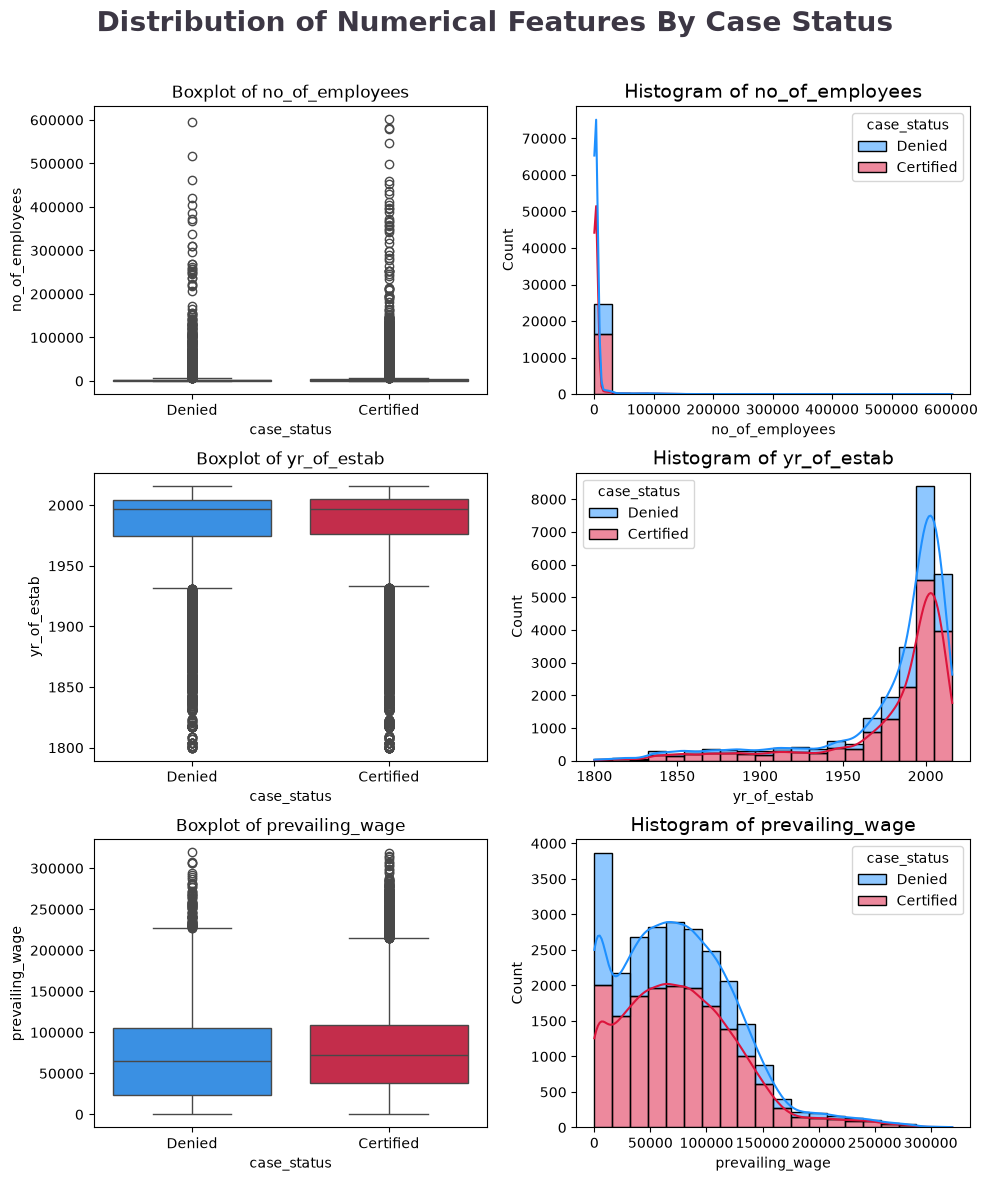

In [39]:

clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By Case Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(continues_features):   
    sns.boxplot(data=df, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
# plt.savefig('images/multivariate_num.png')

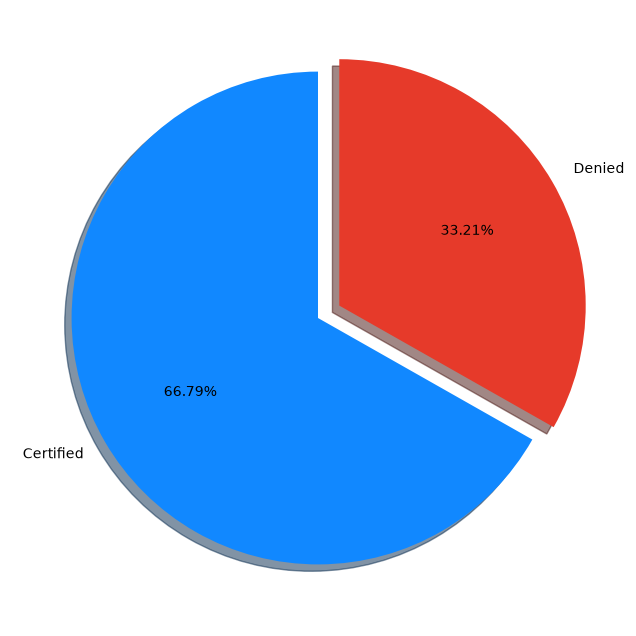

In [40]:
percentage = df.case_status.value_counts(normalize=True)*100
labels = ["Certified","Denied"]

# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff','#e63a2a']
ax.pie(percentage, labels = labels, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

In [41]:

#group data by continent and their count of case_status
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

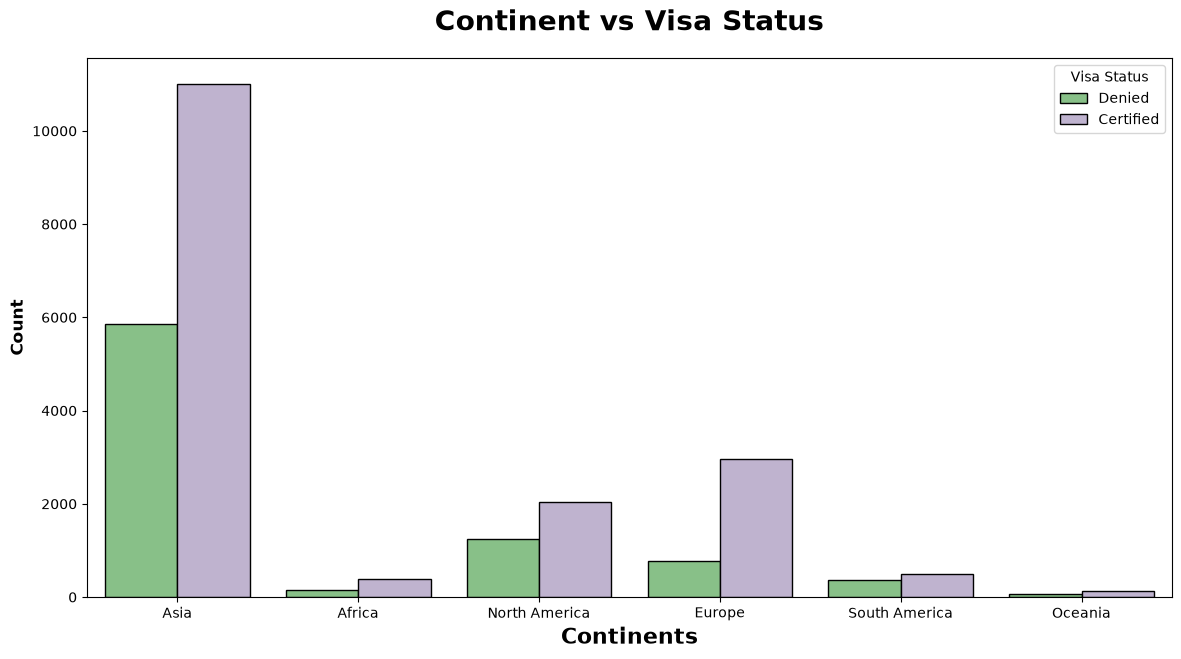

In [42]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continents", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

In [43]:

df2 = df.copy()

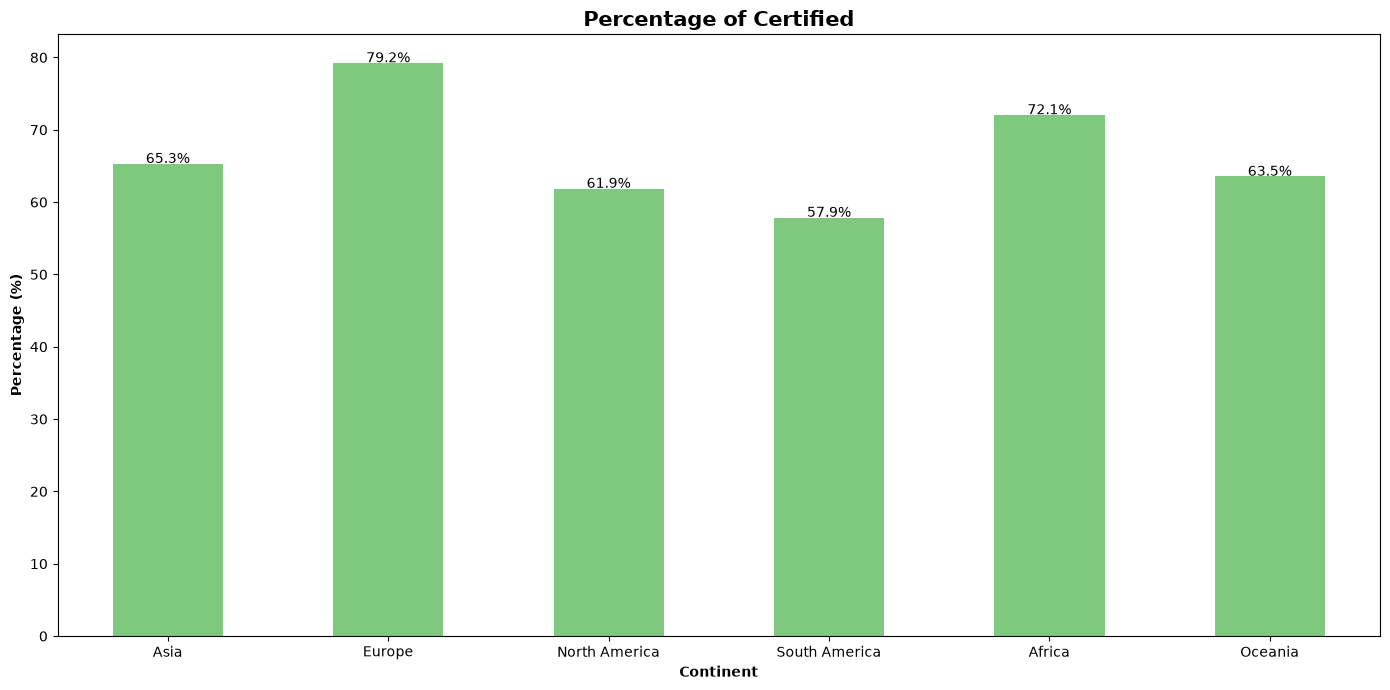

In [45]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by continent
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["continent"].value_counts()
    / df2["continent"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)
    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Continent",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [46]:
#group data by Education and their count of case_status
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

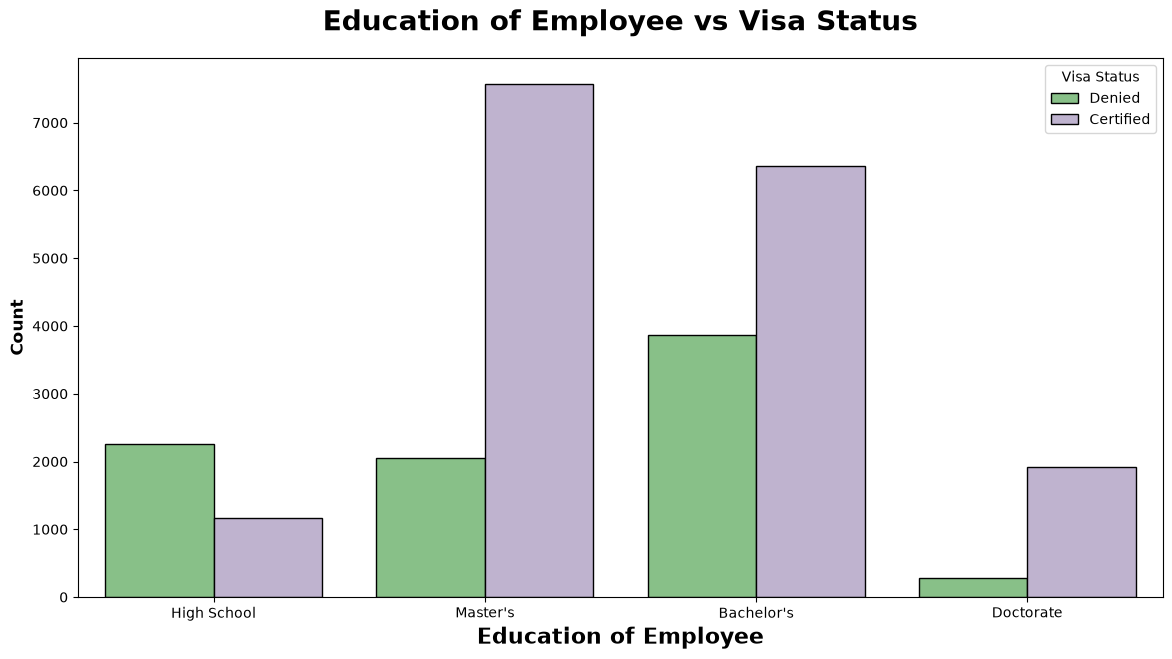

In [47]:

plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Education of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

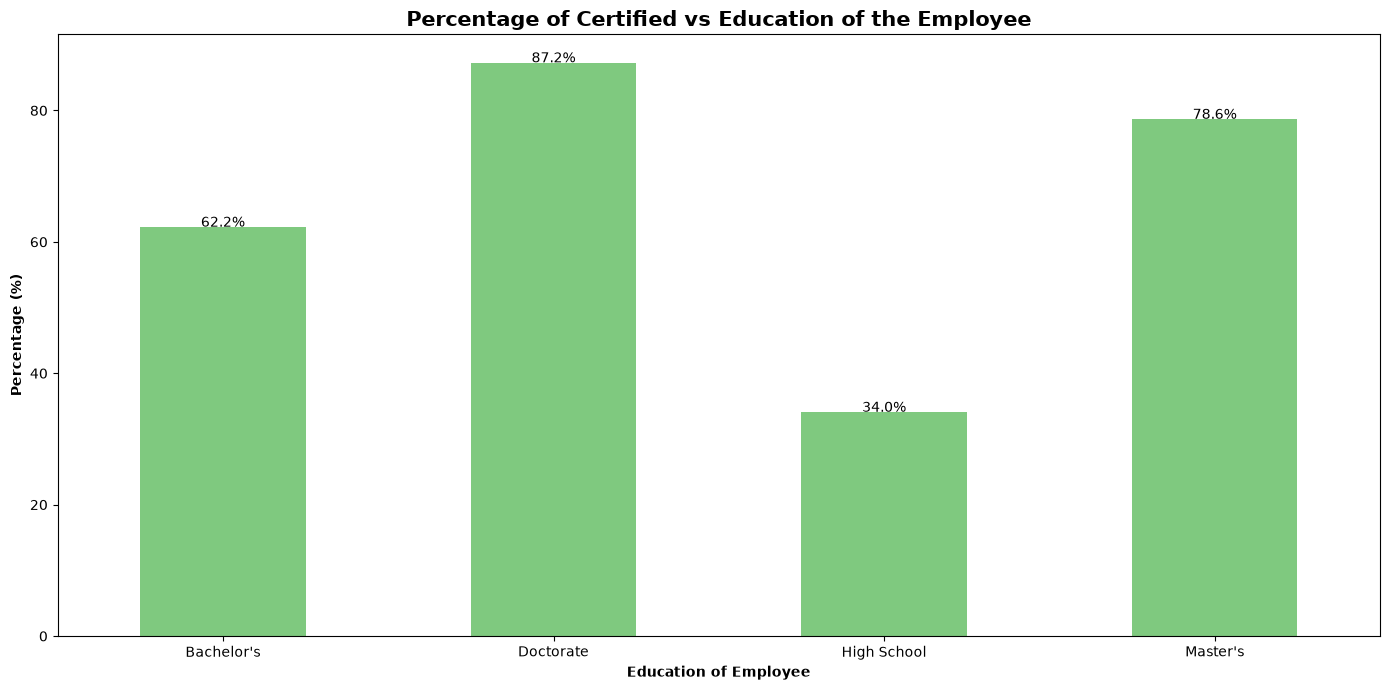

In [49]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by education level
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["education_of_employee"].value_counts()
    / df2["education_of_employee"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified vs Education of the Employee",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)

    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Education of Employee",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [50]:

#group data by has_job_experience and count case_status
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

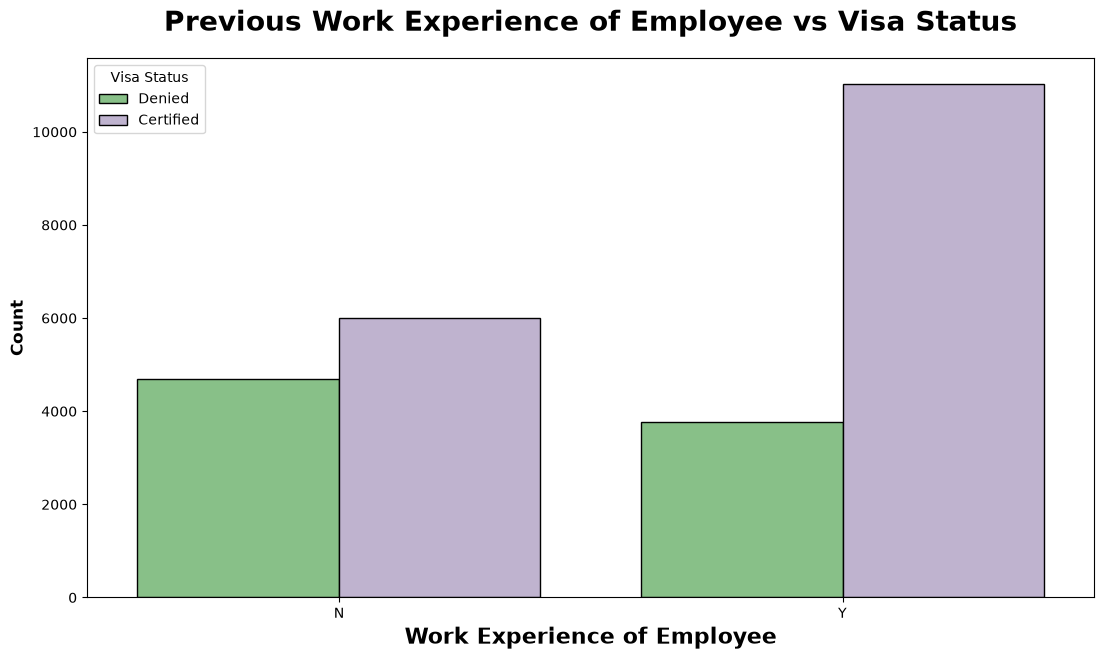

In [51]:
plt.subplots(figsize=(13,7))
sns.countplot(x="has_job_experience",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Previous Work Experience of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Work Experience of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

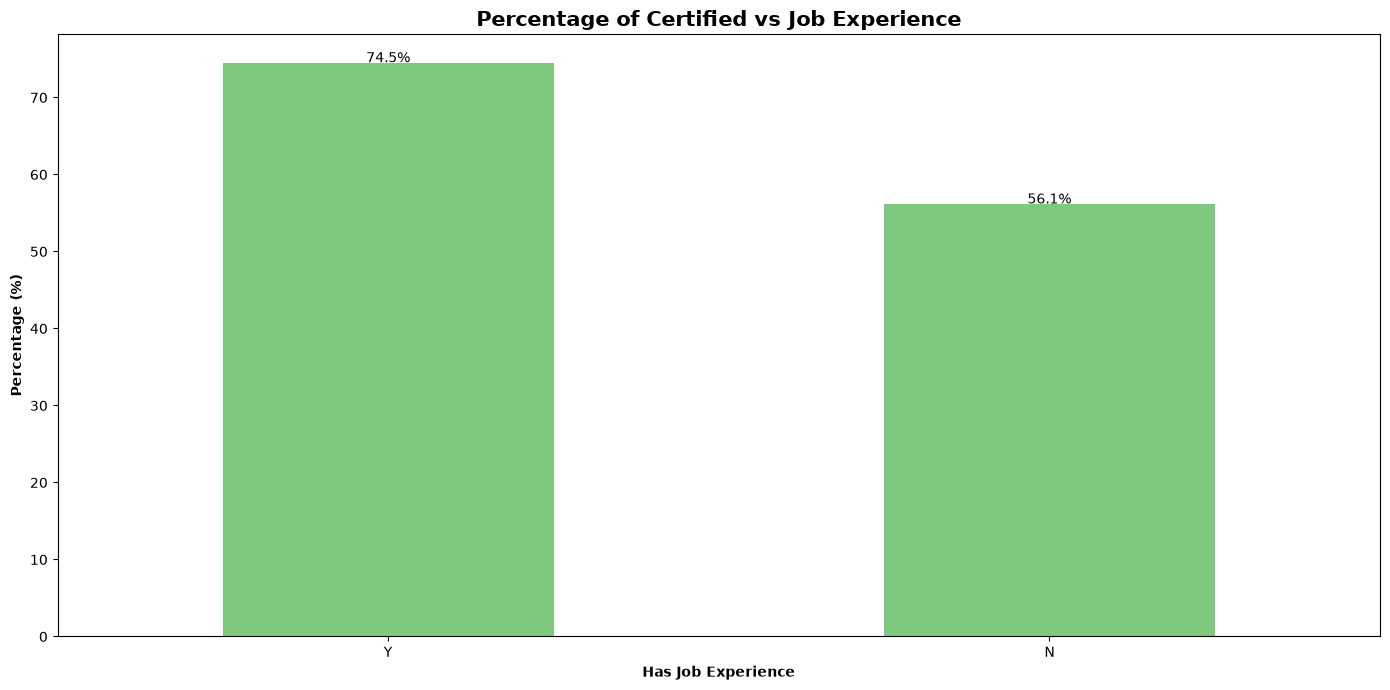

In [53]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by job experience
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["has_job_experience"].value_counts()
    / df2["has_job_experience"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified vs Job Experience",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)

    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Has Job Experience",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [54]:

#group data by requires_job_training and count case_status
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

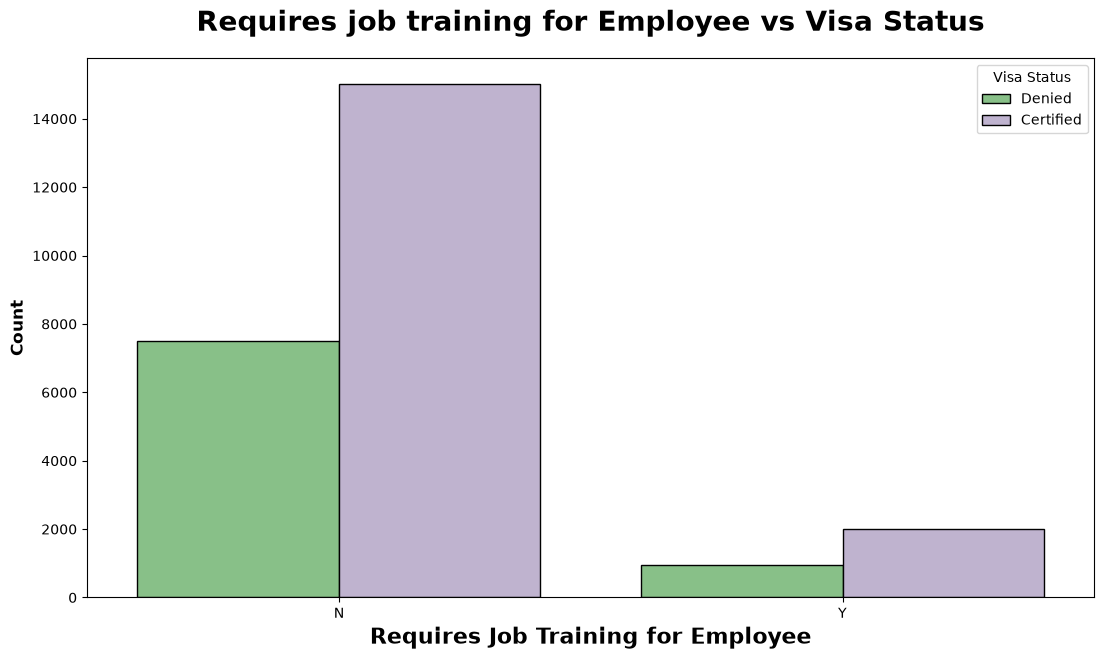

In [55]:

plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

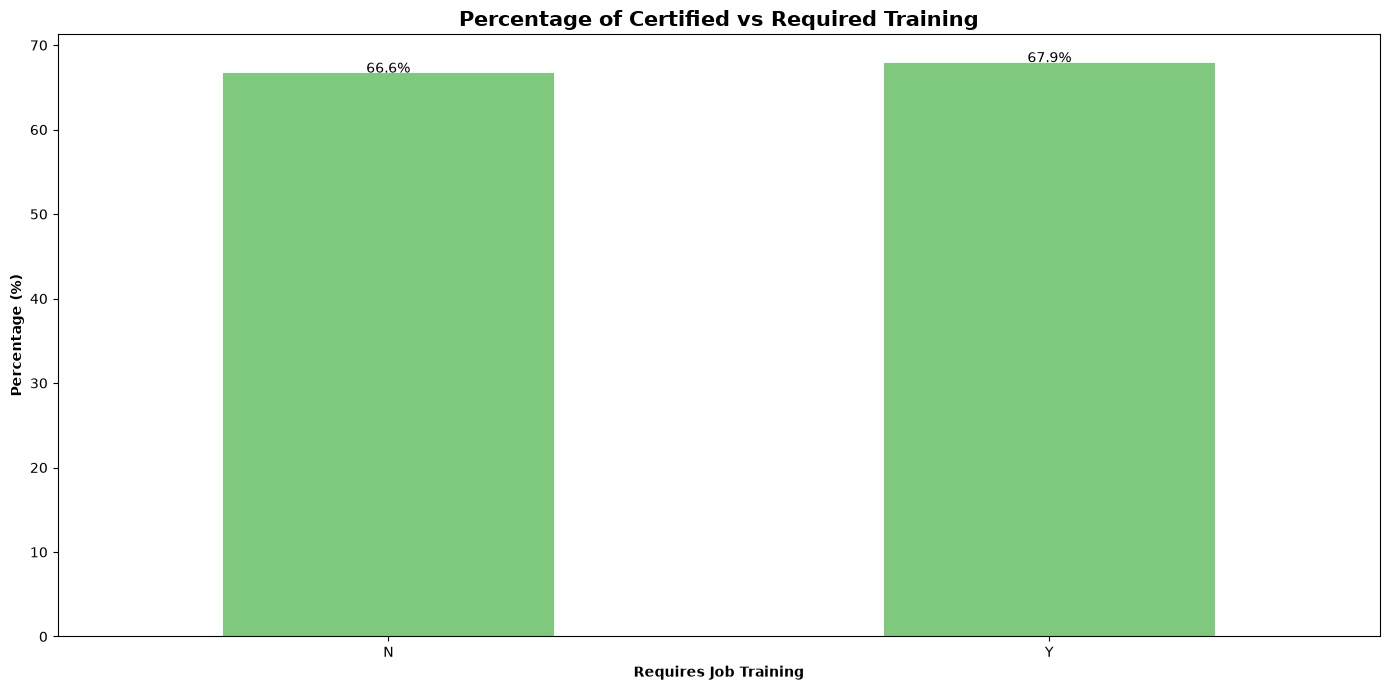

In [57]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by required job training
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["requires_job_training"].value_counts()
    / df2["requires_job_training"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified vs Required Training",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)

    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Requires Job Training",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

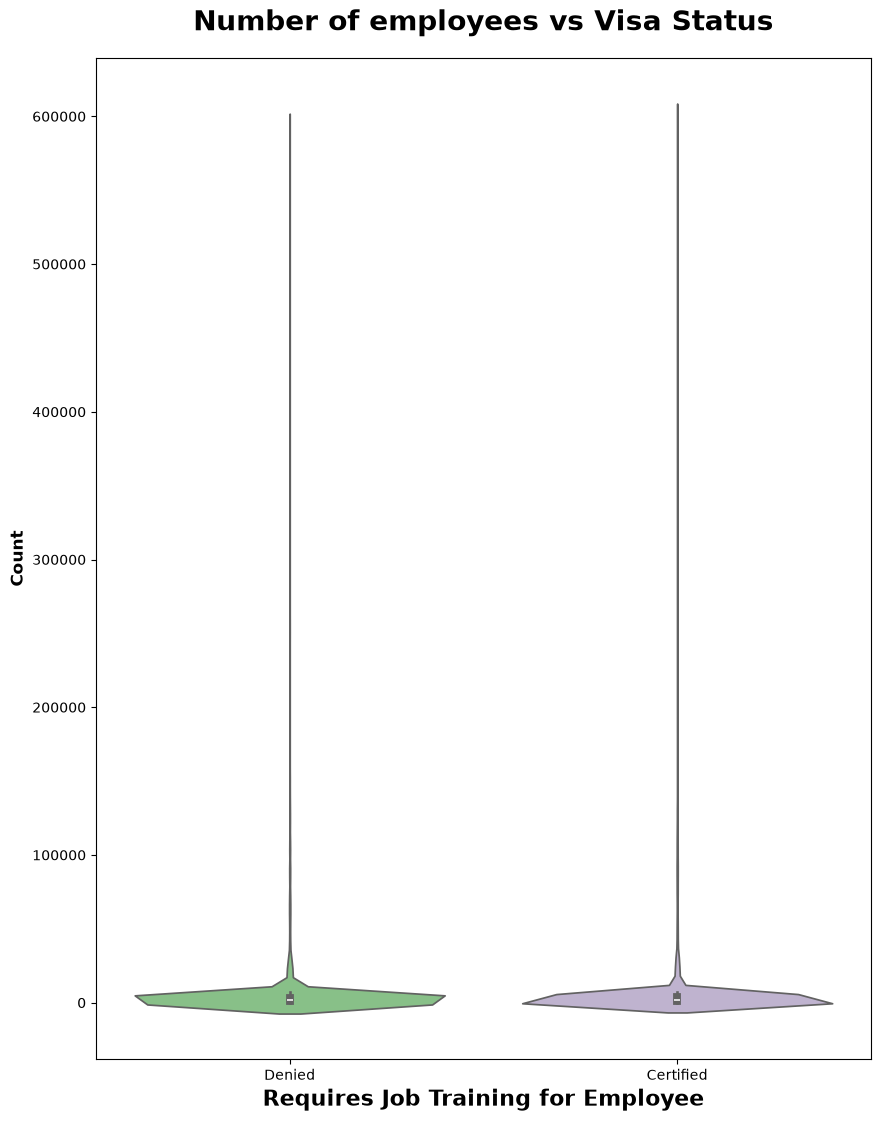

In [58]:
plt.subplots(figsize=(10,13))
sns.violinplot(x="case_status",y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()


In [59]:

#group data by unit_of_wage and count the case_status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

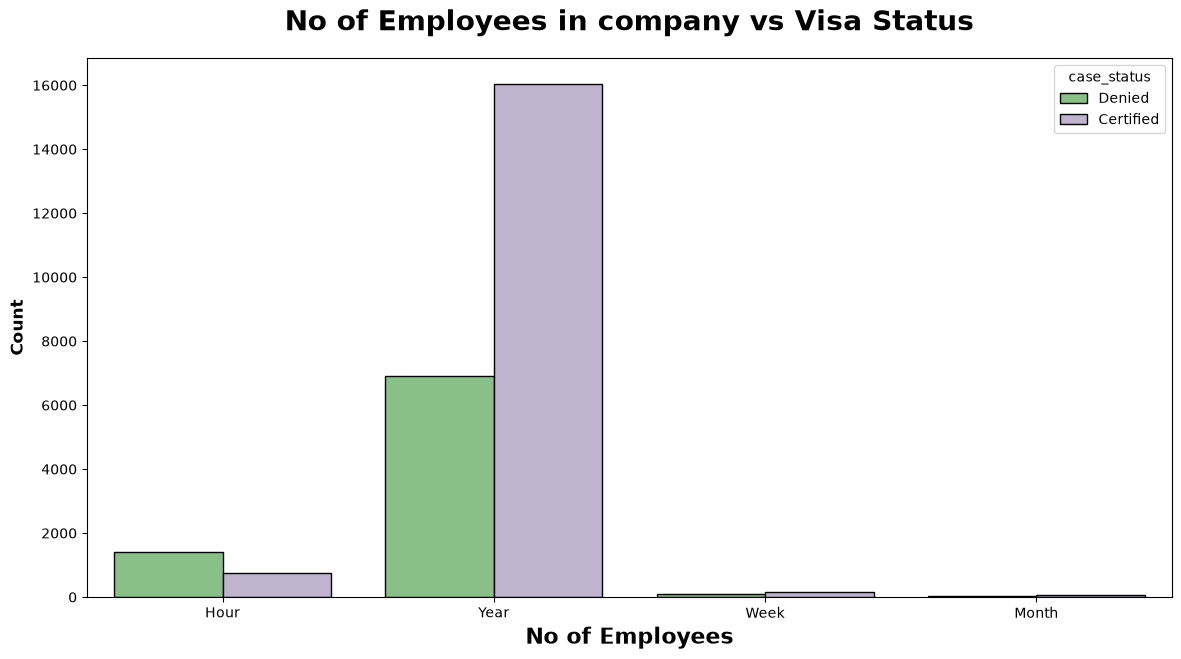

In [60]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage",hue="case_status", data=df,ec='k', palette='Accent')
plt.title("No of Employees in company vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

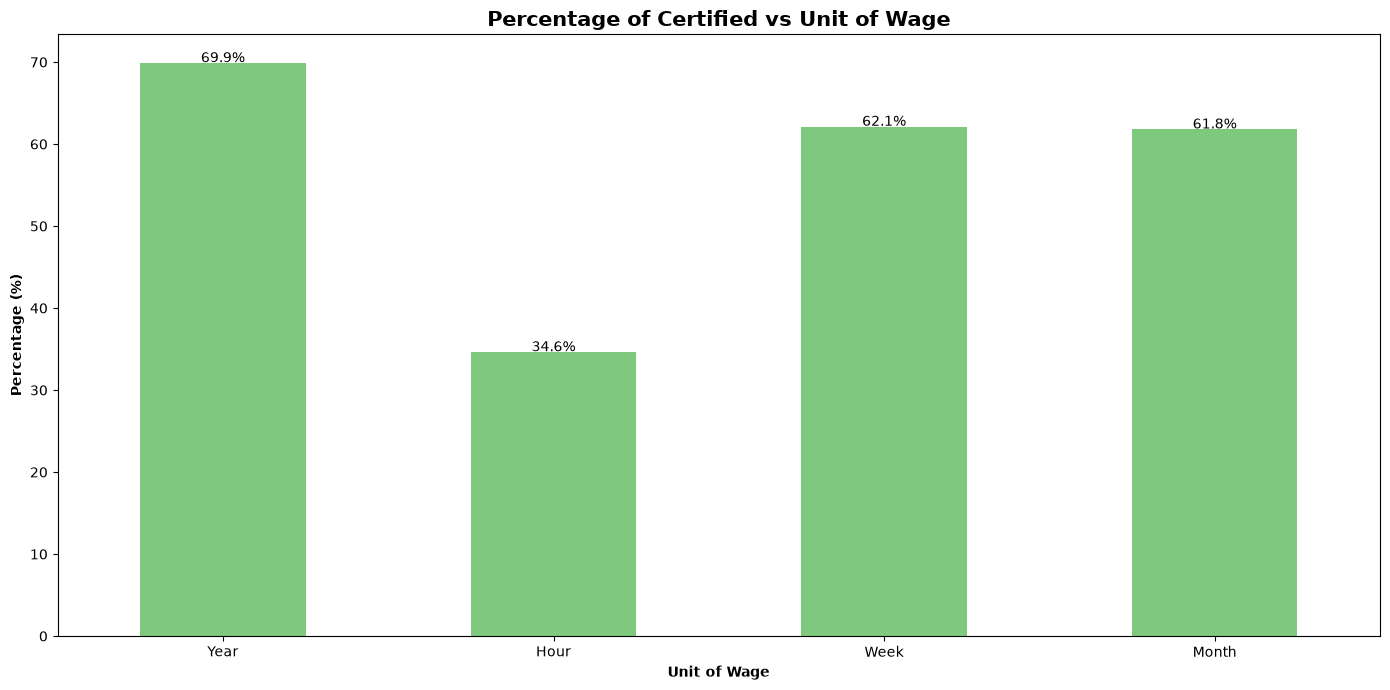

In [62]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by unit of wage
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["unit_of_wage"].value_counts()
    / df2["unit_of_wage"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified vs Unit of Wage",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)

    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Unit of Wage",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

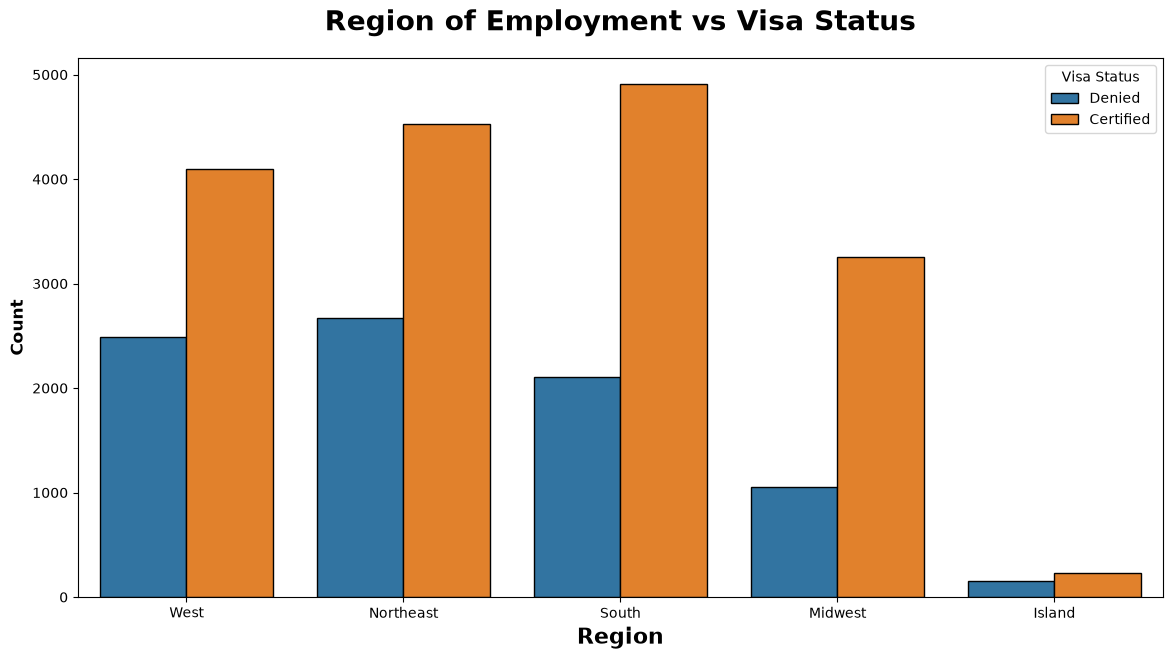

In [63]:
plt.subplots(figsize=(14,7))
sns.countplot(x="region_of_employment",hue="case_status", data=df,ec='k')
plt.title("Region of Employment vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

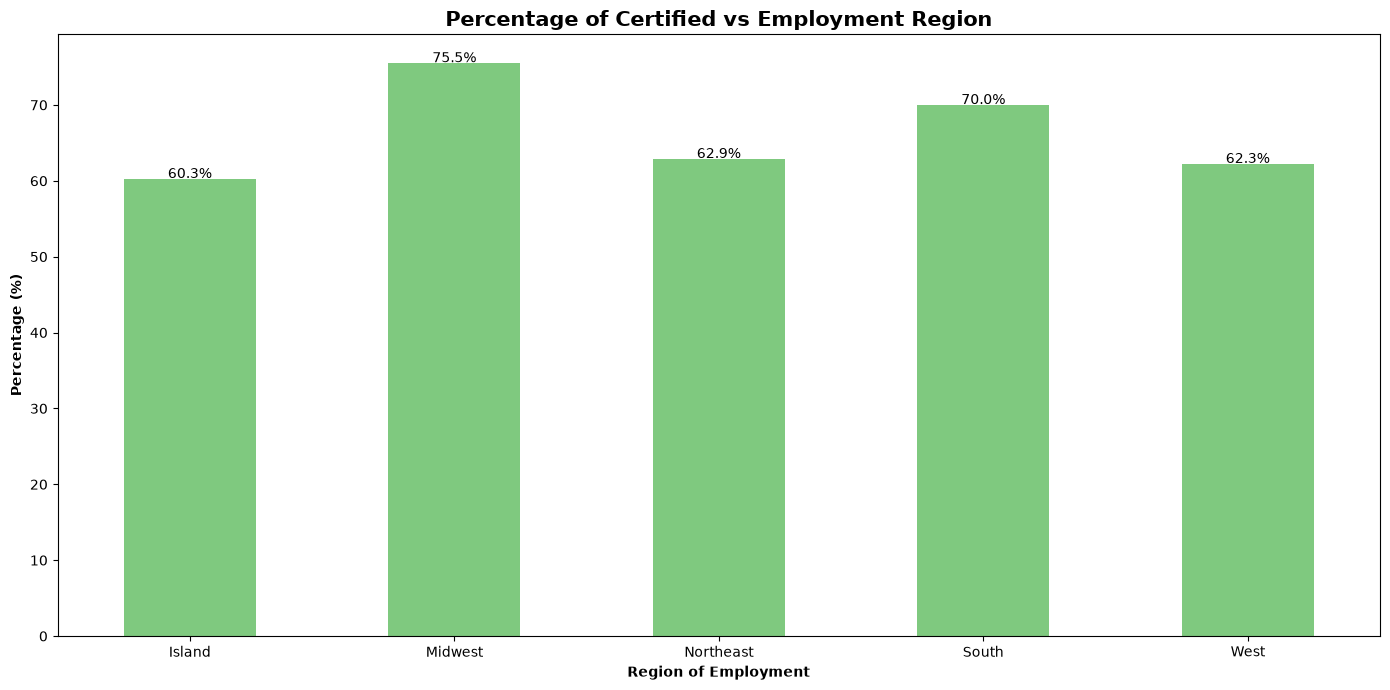

In [64]:
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by employment region
order1 = (
    100
    * df2[df2["case_status"] == "Certified"]["region_of_employment"].value_counts()
    / df2["region_of_employment"].value_counts()
)

# Plot
order1.plot(
    kind="bar",
    stacked=True,
    colormap="Accent"
)

plt.title(
    "Percentage of Certified vs Employment Region",
    fontsize=15,
    fontweight="bold"
)

# Add percentage labels
for n, count in enumerate(order1):
    strt = "{:0.1f}%".format(count)

    plt.text(
        n,
        count + 0.1,
        strt,
        ha="center"
    )

plt.xlabel(
    "Region of Employment",
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [65]:

df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

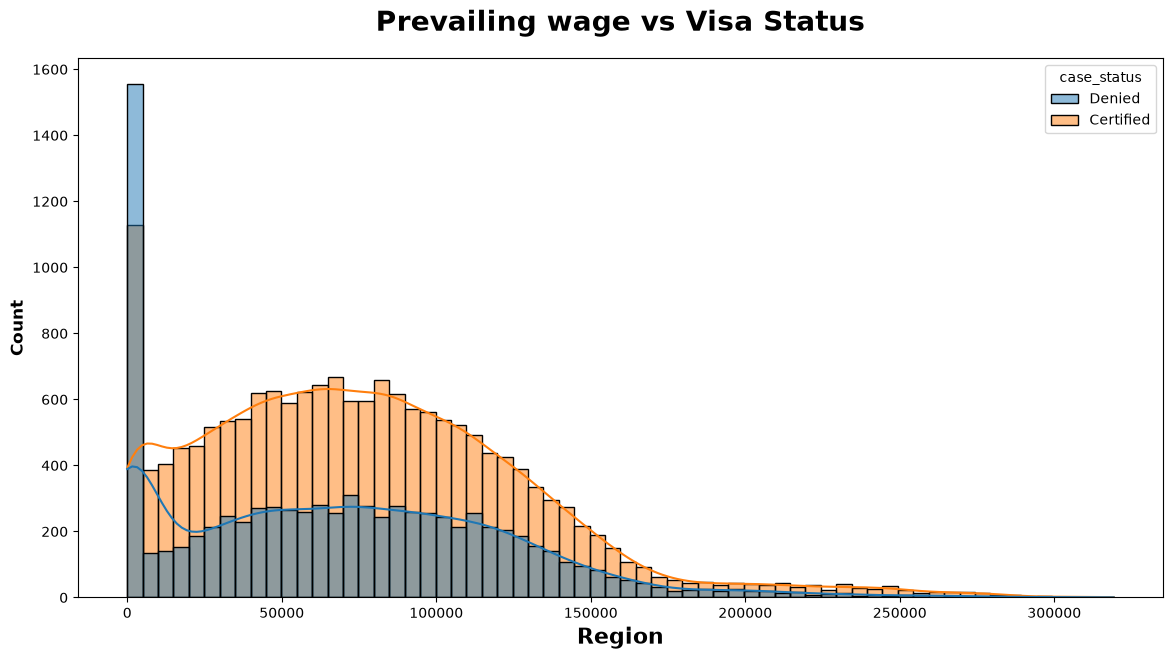

In [66]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

In [67]:
print('Average Prevailing wage based on Employee education')
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Employee education


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


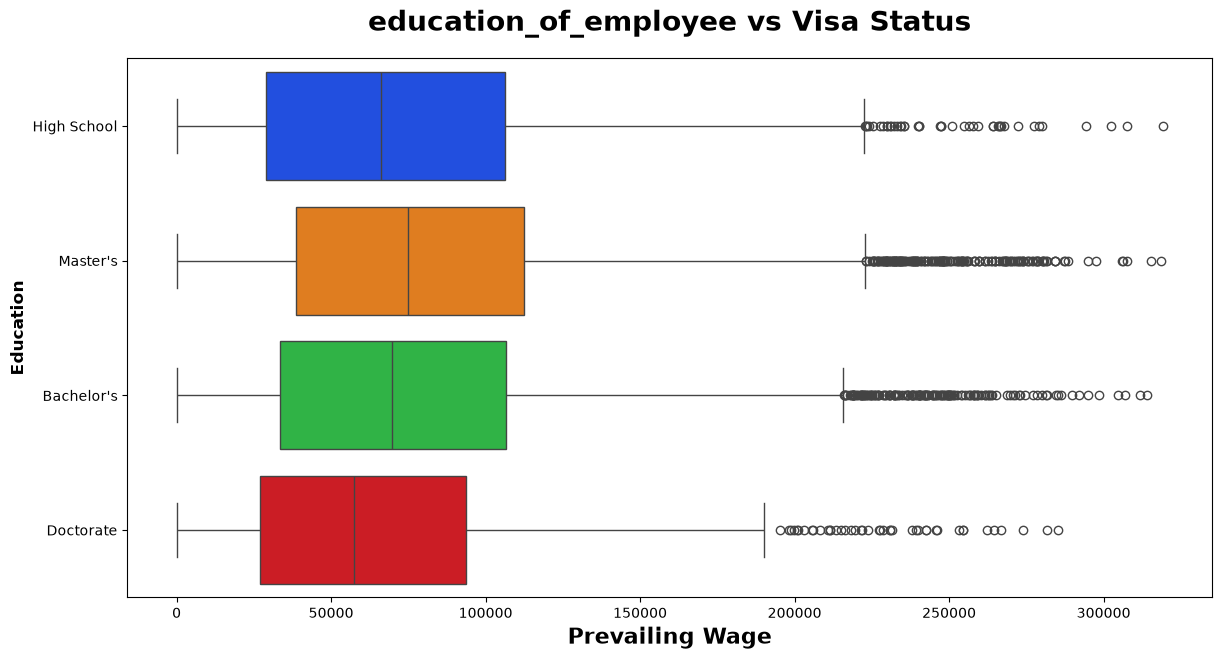

In [68]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.show()

In [69]:

print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


In [70]:
print('Average Prevailing wage based on Continent')
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


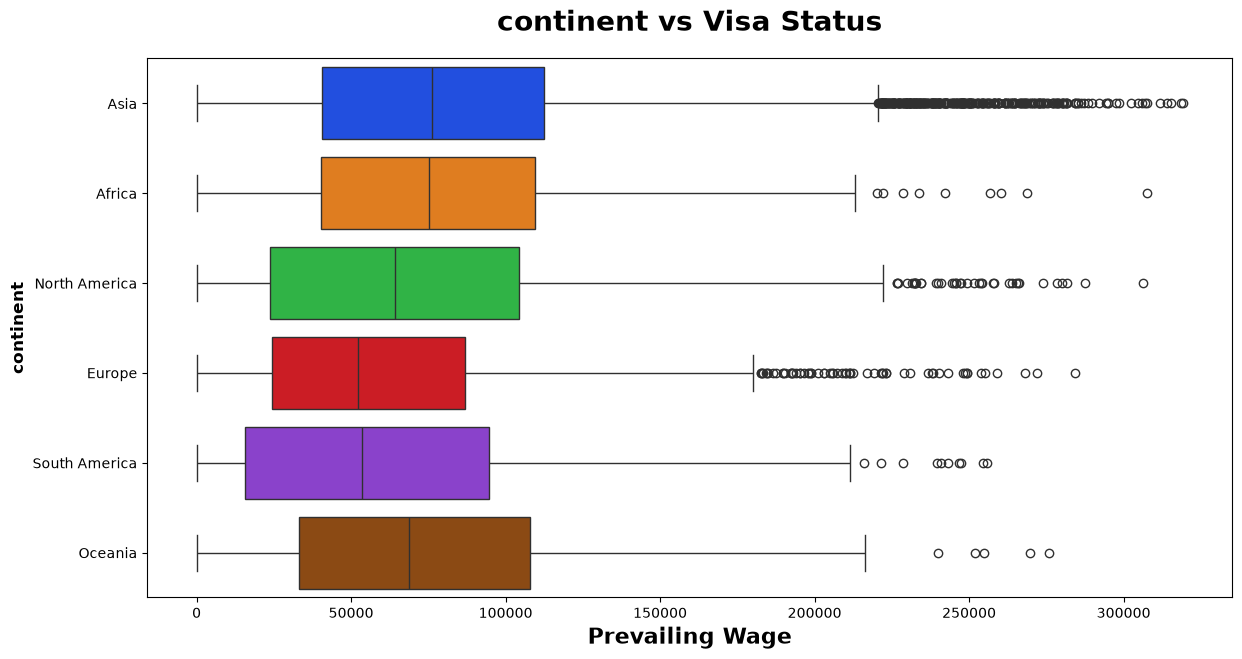

In [71]:

plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

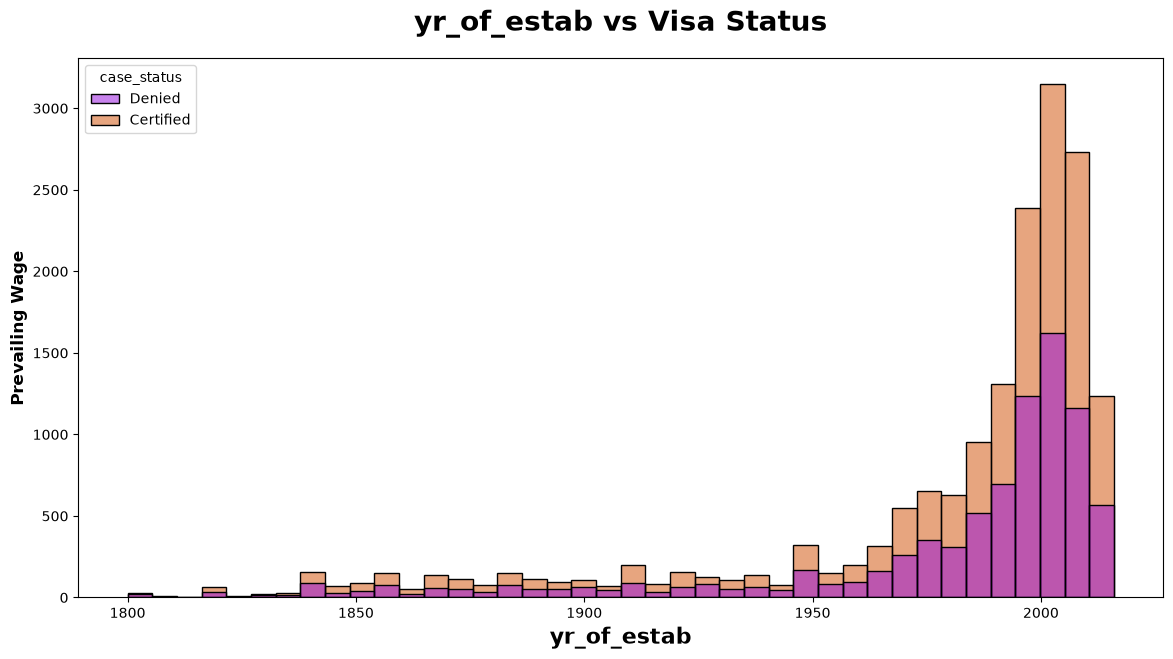

In [72]:
plt.subplots(figsize=(14,7))
sns.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()